In [24]:
import torch
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
from models import ColorizingNet
from utils import visualize_results
import os
import numpy as np
import cv2

# Define device
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [25]:
# Load model
model = ColorizingNet(device)
pretrained_path = "best_colorization_model.pth"
if os.path.exists(pretrained_path):
    state_dict = torch.load(pretrained_path, map_location=device)
    model.load_state_dict(state_dict, strict=False)  # Allow partial loading
    print("Loaded pretrained model with some keys ignored.")
else:
    print("Pretrained model not found.")

Loaded pretrained model with some keys ignored.


In [26]:
# Function to process a single image
def process_image(image_path):
    transformation = transforms.Compose([
        transforms.Resize((256, 256), Image.BICUBIC),
        transforms.ToTensor()
    ])

    image = Image.open(image_path).convert("L")  # Convert to grayscale
    image_tensor = transformation(image).unsqueeze(0).to(device)  # Add batch dimension

    return image_tensor

# Function to display results
def display_results(grayscale_img, colorized_img):
    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.imshow(grayscale_img, cmap="gray")
    plt.title("Grayscale Input")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(colorized_img)
    plt.title("Colorized Output")
    plt.axis("off")

    plt.show()

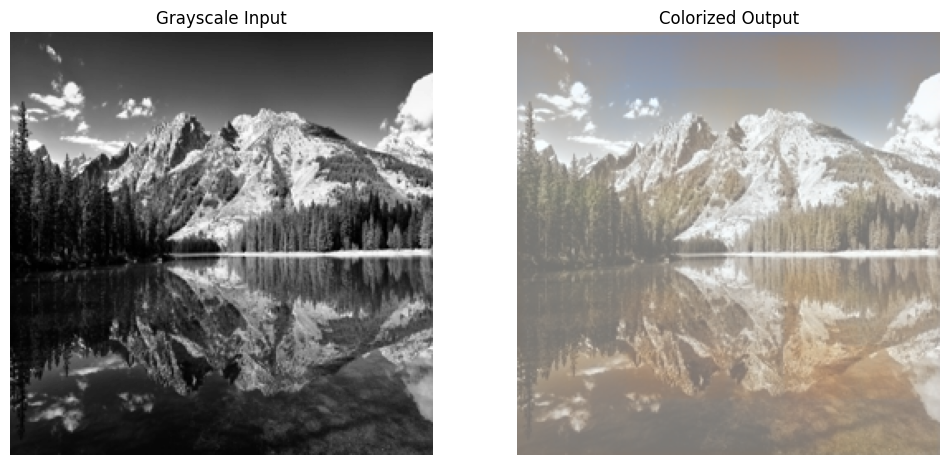

In [49]:
# Test on a single image
image_path = "data/img_color/data/random_images/img.png"  # Update this with the path to your test image
import torch.nn.functional as F  # Ensure this import is present


gray_img_tensor = process_image(image_path)

with torch.no_grad():
    colorized_ab = model(gray_img_tensor)
    # Resize AB channels to match L channel dimensions
    colorized_ab = F.interpolate(colorized_ab, size=(gray_img_tensor.size(2), gray_img_tensor.size(3)), mode='bilinear', align_corners=False)

# Convert to LAB and then to RGB
gray_img = gray_img_tensor.squeeze().cpu().numpy() * 50 + 50
colorized_ab = colorized_ab.squeeze().cpu().numpy() * 110
lab_image = np.concatenate([gray_img[np.newaxis, :, :], colorized_ab], axis=0).transpose(1, 2, 0)
colorized_rgb = cv2.cvtColor(lab_image.astype(np.float32), cv2.COLOR_LAB2RGB)

# Display the results
display_results(gray_img, colorized_rgb)



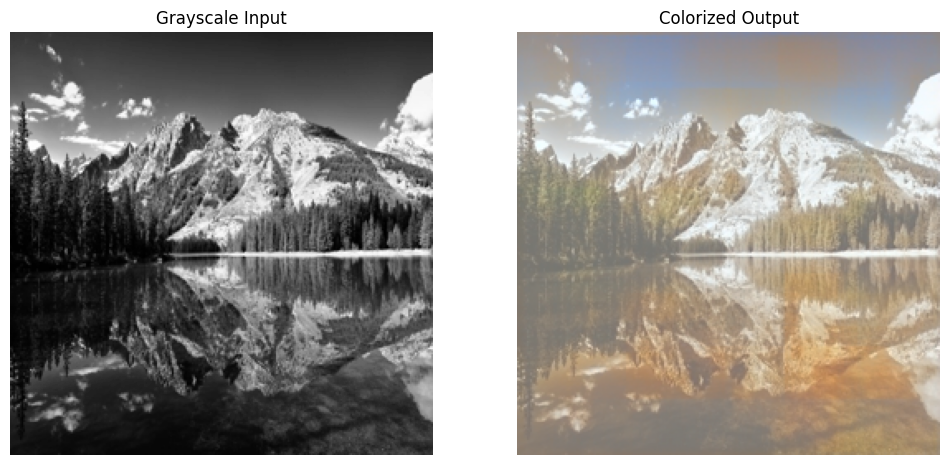

In [50]:
import torch.nn.functional as F  # For resizing the AB channels
from PIL import ImageEnhance
import numpy as np

# Convert to LAB and then to RGB
gray_img = gray_img_tensor.squeeze().cpu().numpy() * 50 + 50  # Convert tensor to NumPy

# Get the model's AB output and resize it to match L channel dimensions
colorized_ab_tensor = model(gray_img_tensor)  # Get the tensor output from the model
colorized_ab_tensor = F.interpolate(colorized_ab_tensor, size=(gray_img_tensor.size(2), gray_img_tensor.size(3)), mode='bilinear', align_corners=False)

colorized_ab = colorized_ab_tensor.squeeze().detach().cpu().numpy() * 125  # Convert to NumPy and scale AB channels

# Create LAB image by concatenating L and AB channels
lab_image = np.concatenate([gray_img[np.newaxis, :, :], colorized_ab], axis=0).transpose(1, 2, 0)
colorized_rgb = cv2.cvtColor(lab_image.astype(np.float32), cv2.COLOR_LAB2RGB)

# Enhance color and contrast
colorized_rgb = np.clip(colorized_rgb, 0, 1)  # Ensure valid range for PIL
colorized_rgb = (colorized_rgb * 255).astype(np.uint8)
colorized_pil = Image.fromarray(colorized_rgb)
enhancer = ImageEnhance.Color(colorized_pil)
colorized_enhanced = enhancer.enhance(1.5)  # Increase the enhancement factor as needed

# Display the results
display_results(gray_img, np.array(colorized_enhanced) / 255.0)
